In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../artifacts/data_ingestion/spam.csv")

In [3]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.shape

(5572, 2)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 542.9 KB


In [6]:
df.describe(include="all")

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [7]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(403)

- The dataset contains 5,572 messages.
- There are two columns: label and message.
- No missing values were found.
- Duplicate messages are present.
- The dataset appears ready for further analysis.

In [9]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [10]:
(df["label"].value_counts(normalize=True) * 100).round(2)

label
ham     86.59
spam    13.41
Name: proportion, dtype: float64

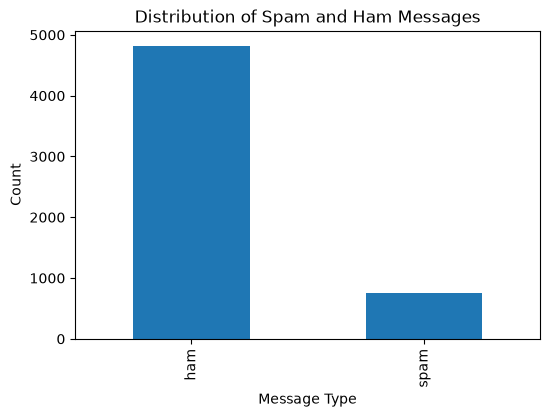

In [11]:
plt.figure(figsize=(6,4))

df["label"].value_counts().plot(kind="bar")

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

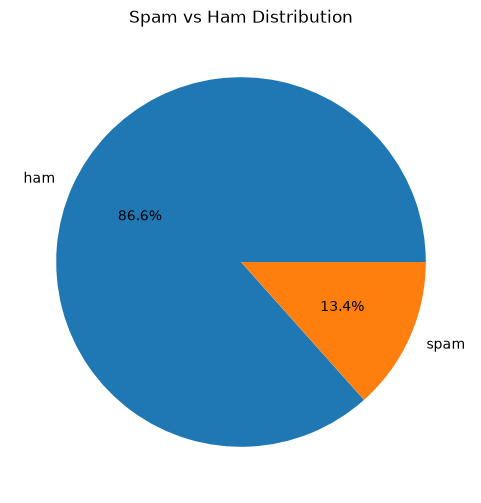

In [12]:
plt.figure(figsize=(6,6))

df["label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Spam vs Ham Distribution")

plt.show()

## Target Variable Analysis

### Observations

- The dataset is imbalanced.
- Ham messages significantly outnumber spam messages.
- Approximately 86% of the messages are ham.
- Approximately 14% are spam.
- Accuracy alone may not be sufficient for model evaluation; Precision, Recall, and F1-score will also be important.

Text Feature Engineering

In this section, we create numerical features from the text messages.

These features help us understand the structural differences between spam and ham messages before applying any NLP preprocessing or machine learning algorithms.

The features created are:

- Number of Characters
- Number of Words
- Number of Sentences

In [13]:
import nltk

In [14]:
nltk.download("punkt")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ANEES\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [18]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ANEES\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [19]:
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize

In [20]:
df["num_characters"] = df["message"].apply(len)

In [21]:
df["num_words"] = df["message"].apply(
    lambda text: len(word_tokenize(text))
)

In [22]:
df["num_sentences"] = df["message"].apply(
    lambda text: len(sent_tokenize(text))
)

In [23]:
df.head()

,label,message,num_characters,num_words,num_sentences
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [24]:
df[
    [
        "num_characters",
        "num_words",
        "num_sentences"
    ]
].describe()

,num_characters,num_words,num_sentences
count,5572.000000,5572.000000,5572.000000
mean,80.489950,18.842785,2.006102
std,59.942907,13.852262,1.539977
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,62.000000,15.000000,2.000000
75%,122.000000,27.000000,3.000000
max,910.000000,220.000000,38.000000


## Observations

Three numerical features were created from the text messages:

- Character Count
- Word Count
- Sentence Count

These features will be used in the next section to compare spam and ham messages and identify structural differences between the two classes.

In [25]:
df.groupby("label")[
    ["num_characters", "num_words", "num_sentences"]
].mean()

,num_characters,num_words,num_sentences
label,,,
ham,71.482487,17.426114,1.846010
spam,138.670683,27.993307,3.040161


### Observation

Spam messages contain more characters, more words, and more sentences than ham messages on average.

This suggests that message length may be a useful indicator for distinguishing spam from legitimate messages.

In [26]:
df.groupby("label")[
    ["num_characters", "num_words", "num_sentences"]
].describe()

num_characters                                                           \
               count        mean        std   min    25%    50%    75%    max   
label                                                                           
ham           4825.0   71.482487  58.440652   2.0   33.0   52.0   93.0  910.0   
spam           747.0  138.670683  28.873603  13.0  133.0  149.0  157.0  223.0   

      num_words             ...              num_sentences            \
          count       mean  ...   75%    max         count      mean   
label                       ...                                        
ham      4825.0  17.426114  ...  23.0  220.0        4825.0  1.846010   
spam      747.0  27.993307  ...  32.0   46.0         747.0  3.040161   

                                           
            std  min  25%  50%  75%   max  
label                                      
ham    1.475377  1.0  1.0  1.0  2.0  38.0  
spam   1.548499  1.0  2.0  3.0  4.0   9.0  

[2 rows x 24 columns]

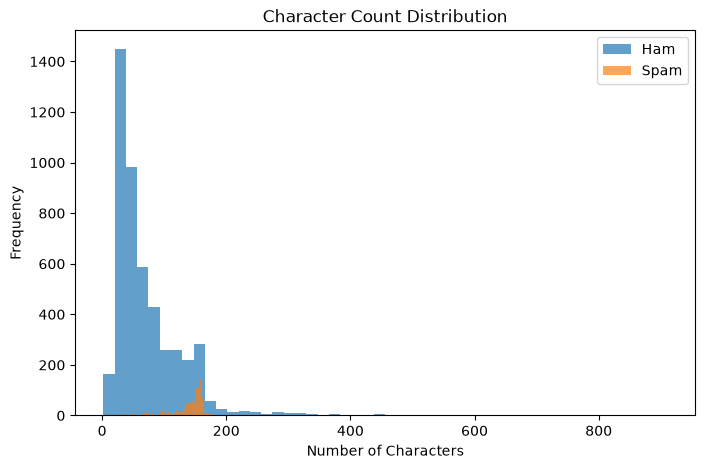

In [27]:
plt.figure(figsize=(8,5))

plt.hist(
    df[df["label"] == "ham"]["num_characters"],
    bins=50,
    alpha=0.7,
    label="Ham"
)

plt.hist(
    df[df["label"] == "spam"]["num_characters"],
    bins=50,
    alpha=0.7,
    label="Spam"
)

plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.title("Character Count Distribution")

plt.legend()

plt.show()

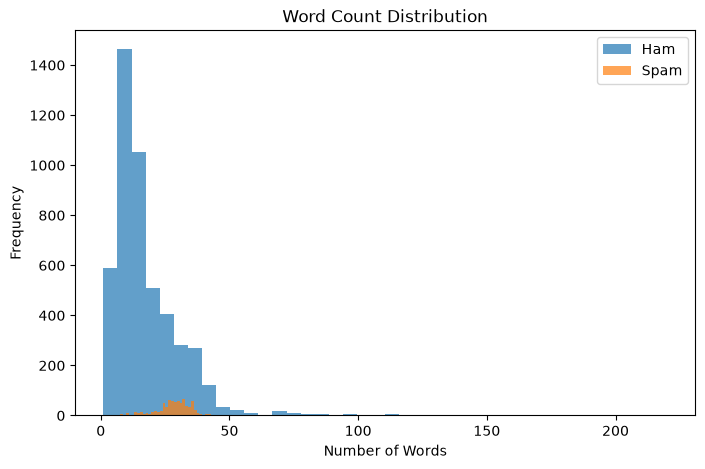

In [28]:
plt.figure(figsize=(8,5))

plt.hist(
    df[df["label"] == "ham"]["num_words"],
    bins=40,
    alpha=0.7,
    label="Ham"
)

plt.hist(
    df[df["label"] == "spam"]["num_words"],
    bins=40,
    alpha=0.7,
    label="Spam"
)

plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Word Count Distribution")

plt.legend()

plt.show()

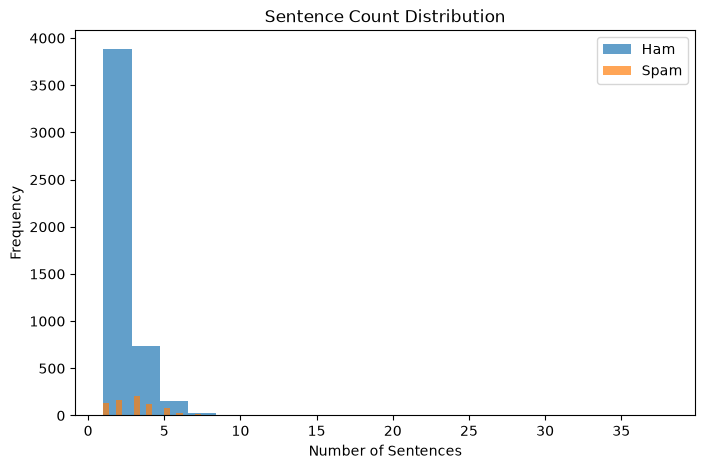

In [29]:
plt.figure(figsize=(8,5))

plt.hist(
    df[df["label"] == "ham"]["num_sentences"],
    bins=20,
    alpha=0.7,
    label="Ham"
)

plt.hist(
    df[df["label"] == "spam"]["num_sentences"],
    bins=20,
    alpha=0.7,
    label="Spam"
)

plt.xlabel("Number of Sentences")
plt.ylabel("Frequency")
plt.title("Sentence Count Distribution")

plt.legend()

plt.show()

<Figure size 600x400 with 0 Axes>

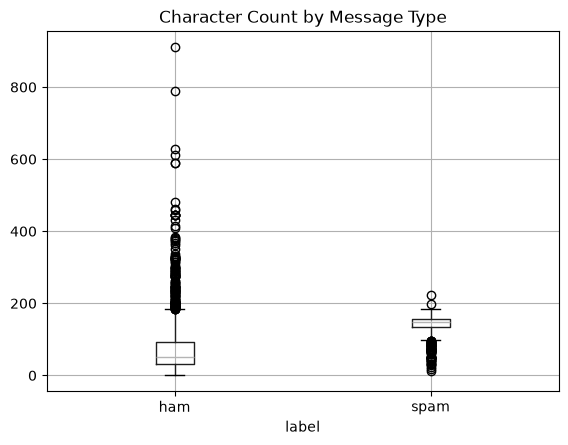

In [30]:
plt.figure(figsize=(6,4))

df.boxplot(column="num_characters", by="label")

plt.title("Character Count by Message Type")
plt.suptitle("")

plt.show()

<Figure size 600x400 with 0 Axes>

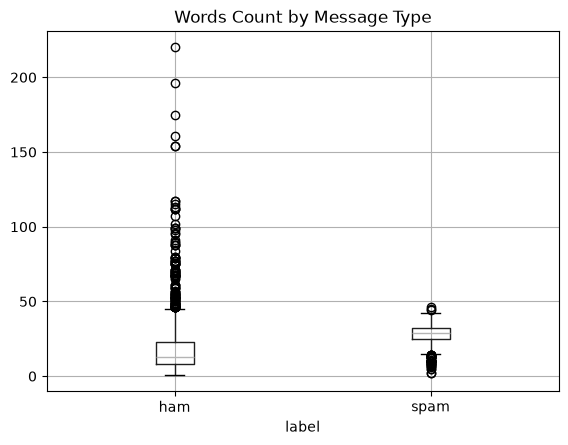

In [32]:
plt.figure(figsize=(6,4))

df.boxplot(column="num_words", by="label")

plt.title("Words Count by Message Type")
plt.suptitle("")

plt.show()

<Figure size 600x400 with 0 Axes>

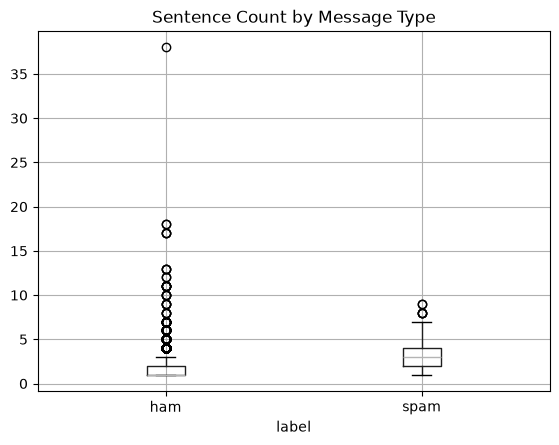

In [33]:
plt.figure(figsize=(6,4))

df.boxplot(column="num_sentences", by="label")

plt.title("Sentence Count by Message Type")
plt.suptitle("")

plt.show()

## Observations

- Spam messages are generally longer than ham messages.
- Spam messages contain more words.
- Spam messages often consist of more sentences.
- There is overlap between the two classes, so message length alone cannot perfectly separate spam from ham.
- Some outliers exist, especially among spam messages.

In [34]:
from collections import Counter

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import string

In [35]:
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ANEES\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [36]:
def get_common_words(messages):
    return Counter(
        token
          for message in messages
          for token in word_tokenize(message.lower())
          if token.isalpha() and token not in stop_words
    )
    # words = []

    # for message in messages:

    #     tokens = word_tokenize(message.lower())

    #     for token in tokens:

    #         if (
    #             token.isalpha()
    #             and token not in stop_words
    #         ):
    #             words.append(token)

    # return Counter(words)

In [37]:
ham_words = get_common_words(
    df[df["label"] == "ham"]["message"]
)

ham_words.most_common(20)

[('u', 994),
 ('gt', 318),
 ('lt', 316),
 ('get', 302),
 ('go', 251),
 ('ur', 247),
 ('ok', 246),
 ('got', 245),
 ('know', 237),
 ('like', 233),
 ('call', 232),
 ('good', 231),
 ('come', 230),
 ('time', 198),
 ('love', 197),
 ('day', 191),
 ('ü', 173),
 ('going', 169),
 ('one', 168),
 ('want', 164)]

In [38]:
spam_words = get_common_words(
    df[df["label"] == "spam"]["message"]
)

spam_words.most_common(20)

[('call', 346),
 ('free', 219),
 ('txt', 156),
 ('ur', 144),
 ('u', 142),
 ('mobile', 123),
 ('text', 121),
 ('stop', 118),
 ('claim', 113),
 ('reply', 104),
 ('prize', 92),
 ('get', 84),
 ('send', 69),
 ('new', 69),
 ('nokia', 65),
 ('urgent', 63),
 ('cash', 62),
 ('win', 60),
 ('contact', 56),
 ('service', 55)]

## Observations

### Ham Messages

- Mostly contain conversational words.
- Frequently include personal communication terms.

### Spam Messages

- Frequently contain promotional words.
- Common terms include "free", "win", "claim", "call", and "prize".
- These words are strong indicators of spam messages.

In [39]:
from wordcloud import WordCloud

In [40]:
ham_text = " ".join(
    df[df["label"] == "ham"]["message"]
)

In [41]:
ham_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(ham_text)

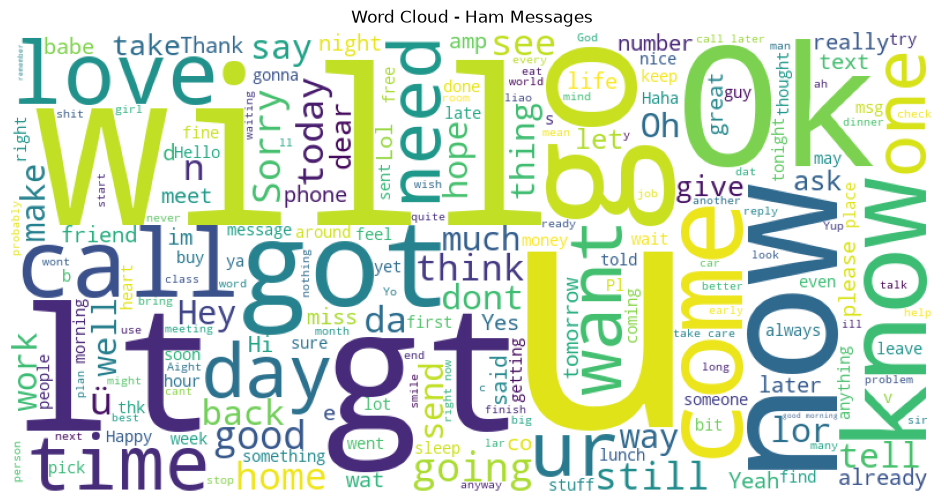

In [42]:
plt.figure(figsize=(12,6))

plt.imshow(ham_wordcloud)

plt.axis("off")

plt.title("Word Cloud - Ham Messages")

plt.show()

In [43]:
spam_text = " ".join(
    df[df["label"] == "spam"]["message"]
)

In [44]:
spam_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(spam_text)

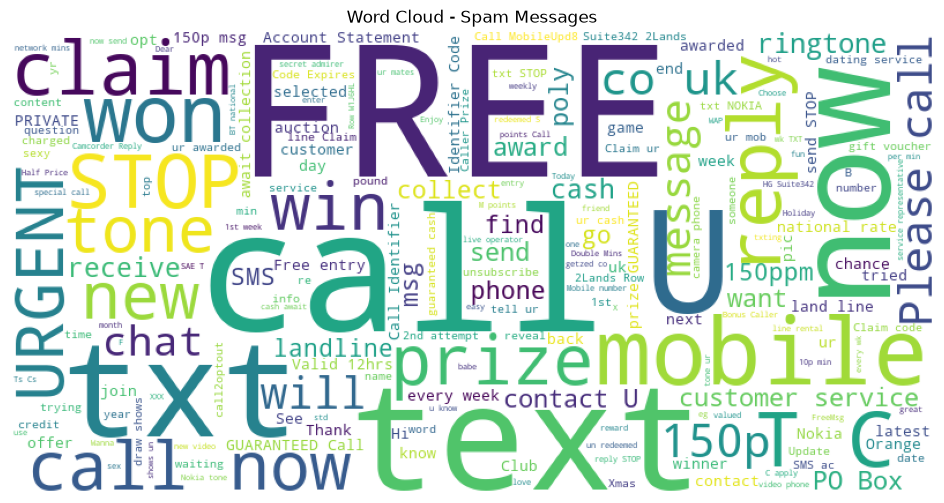

In [45]:
plt.figure(figsize=(12,6))

plt.imshow(spam_wordcloud)

plt.axis("off")

plt.title("Word Cloud - Spam Messages")

plt.show()

## Word Cloud Observations

### Ham Messages

- The most prominent words are related to everyday conversations.
- Most messages appear informal and personal.

### Spam Messages

- Promotional words such as "free", "call", "win", and "claim" dominate.
- This suggests that vocabulary is an important feature for spam classification.

In [46]:
from sklearn.feature_extraction.text import CountVectorizer

In [47]:
def get_top_ngrams(messages, n=2, top_k=20):

    vectorizer = CountVectorizer(
        stop_words="english",
        ngram_range=(n, n)
    )

    X = vectorizer.fit_transform(messages)

    frequencies = X.sum(axis=0).A1

    words = vectorizer.get_feature_names_out()

    ngrams = list(zip(words, frequencies))

    ngrams = sorted(
        ngrams,
        key=lambda x: x[1],
        reverse=True
    )

    return ngrams[:top_k]

In [48]:
ham_bigrams = get_top_ngrams(
    df[df["label"]=="ham"]["message"],
    n=2
)

ham_bigrams

[('lt gt', np.int64(276)),
 ('ll later', np.int64(42)),
 ('let know', np.int64(40)),
 ('sorry ll', np.int64(39)),
 ('good morning', np.int64(32)),
 ('don know', np.int64(24)),
 ('decimal gt', np.int64(23)),
 ('lt decimal', np.int64(23)),
 ('new year', np.int64(23)),
 ('ok lor', np.int64(22)),
 ('pls send', np.int64(22)),
 ('good night', np.int64(20)),
 ('just got', np.int64(20)),
 ('happy new', np.int64(19)),
 ('gt lt', np.int64(18)),
 ('hi hi', np.int64(18)),
 ('wat time', np.int64(18)),
 ('great day', np.int64(17)),
 ('dont know', np.int64(16)),
 ('send message', np.int64(16))]

In [49]:
spam_bigrams = get_top_ngrams(
    df[df["label"]=="spam"]["message"],
    n=2
)

spam_bigrams

[('po box', np.int64(27)),
 ('1000 cash', np.int64(23)),
 ('prize guaranteed', np.int64(22)),
 ('send stop', np.int64(21)),
 ('national rate', np.int64(20)),
 ('await collection', np.int64(19)),
 ('selected receive', np.int64(19)),
 ('land line', np.int64(18)),
 ('urgent mobile', np.int64(18)),
 ('150p msg', np.int64(17)),
 ('chance win', np.int64(17)),
 ('customer service', np.int64(17)),
 ('prize claim', np.int64(17)),
 ('valid 12hrs', np.int64(17)),
 ('account statement', np.int64(16)),
 ('free entry', np.int64(16)),
 ('identifier code', np.int64(16)),
 ('txt stop', np.int64(16)),
 ('2lands row', np.int64(15)),
 ('dating service', np.int64(15))]

In [50]:
import pandas as pd

spam_bigram_df = pd.DataFrame(
    spam_bigrams,
    columns=["Bigram","Count"]
)

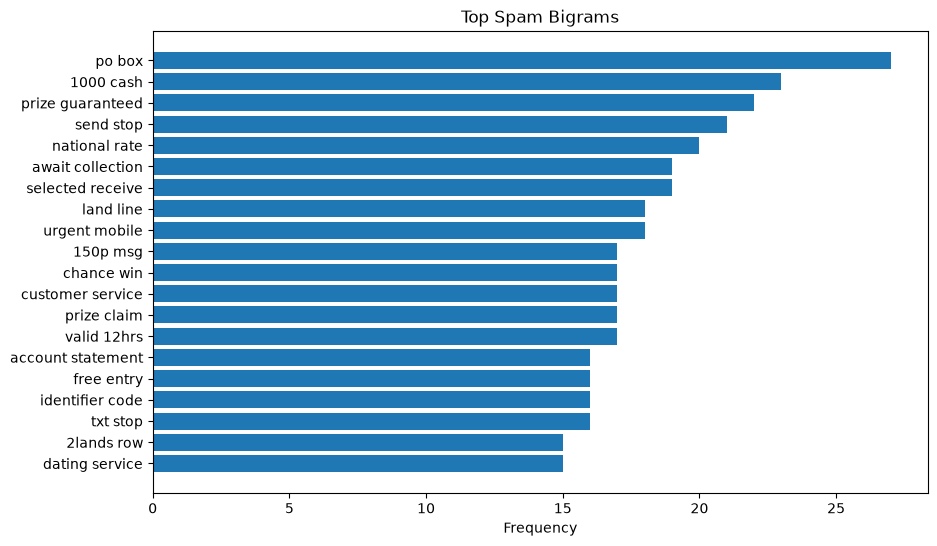

In [51]:
plt.figure(figsize=(10,6))

plt.barh(
    spam_bigram_df["Bigram"],
    spam_bigram_df["Count"]
)

plt.title("Top Spam Bigrams")

plt.xlabel("Frequency")

plt.gca().invert_yaxis()

plt.show()

In [52]:
spam_trigrams = get_top_ngrams(
    df[df["label"]=="spam"]["message"],
    n=3
)

spam_trigrams

[('draw shows won', np.int64(15)),
 ('suite342 2lands row', np.int64(15)),
 ('land line claim', np.int64(14)),
 ('2003 account statement', np.int64(13)),
 ('private 2003 account', np.int64(13)),
 ('800 redeemed points', np.int64(12)),
 ('guaranteed 1000 cash', np.int64(12)),
 ('shows 800 redeemed', np.int64(12)),
 ('2lands row w1j6hl', np.int64(11)),
 ('bonus caller prize', np.int64(11)),
 ('bt national rate', np.int64(11)),
 ('camcorder reply 08000930705', np.int64(11)),
 ('hg suite342 2lands', np.int64(11)),
 ('urgent trying contact', np.int64(11)),
 ('week just txt', np.int64(11)),
 ('2000 prize guaranteed', np.int64(10)),
 ('cash await collection', np.int64(10)),
 ('customer service representative', np.int64(10)),
 ('ntt po box', np.int64(10)),
 ('speak live operator', np.int64(10))]

## N-Gram Analysis

### Ham Messages

- Most bigrams represent everyday conversations.
- Common phrases include greetings, scheduling, and personal communication.

### Spam Messages

- Promotional phrases dominate.
- Common phrases include "free entry", "call now", "claim prize", and "text stop".

These multi-word phrases provide stronger contextual information than individual words and can improve text classification models.